In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Load dataset
df = pd.read_csv('SpotifyFeatures.csv')

# Select audio features
features = ['danceability','energy','loudness','tempo','valence']
X = df[features]

# Remove missing values
X = X.dropna()

df = df.loc[X.index]

df.head()

,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0,0.611,0.389,99373,0.910,0.000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814
1,Movie,Martin & les fées,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1,0.246,0.590,137373,0.737,0.000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3,0.952,0.663,170267,0.131,0.000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368
3,Movie,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0Gc6TVm52BwZD07Ki6tIvf,0,0.703,0.240,152427,0.326,0.000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227
4,Movie,Fabien Nataf,Ouverture,0IuslXpMROHdEPvSl1fTQK,4,0.950,0.331,82625,0.225,0.123,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390


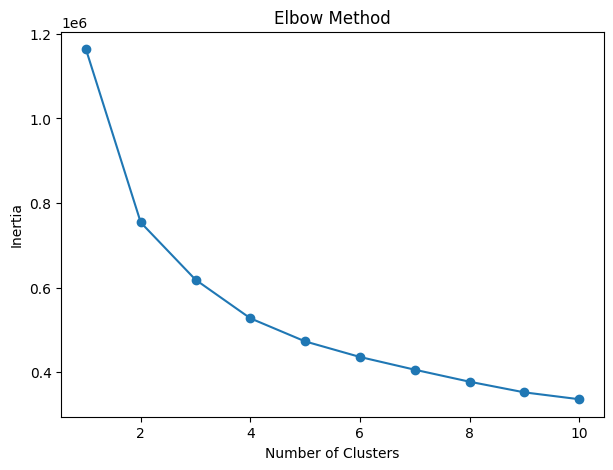

In [ ]:
# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow method
inertia = []

for k in range(1,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(7,5))
plt.plot(range(1,11), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

# Apply KMeans
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df['cluster'] = clusters

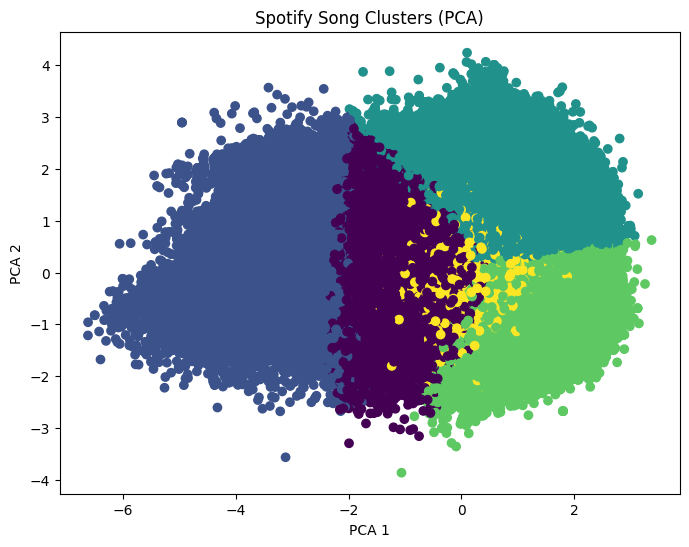

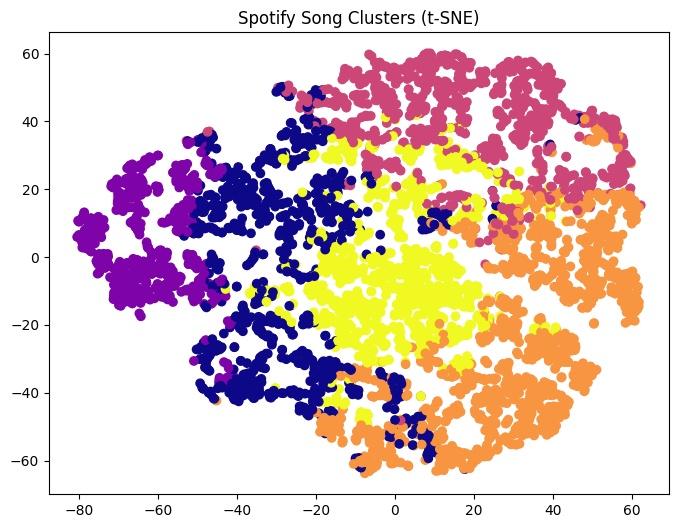

         danceability    energy   loudness       tempo   valence
cluster                                                         
0            0.558582  0.363649 -11.856957  114.804062  0.328522
1            0.265238  0.134341 -21.359480   98.652256  0.132196
2            0.503520  0.751289  -6.134783  160.012168  0.505394
3            0.727116  0.666534  -7.317571  111.974085  0.733104
4            0.548222  0.749618  -6.320722  100.064440  0.371678


In [ ]:
# PCA Visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df['cluster'], cmap='viridis')
plt.title("Spotify Song Clusters (PCA)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

# t-SNE Visualization (sample for faster computation)
sample_df = df.sample(5000, random_state=42)

X_sample = sample_df[['danceability','energy','loudness','tempo','valence']]

scaler = StandardScaler()
X_sample_scaled = scaler.fit_transform(X_sample)

tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_sample_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=sample_df['cluster'], cmap='plasma')
plt.title("Spotify Song Clusters (t-SNE)")
plt.show()

# Cluster analysis
cluster_analysis = df.groupby('cluster')[features].mean()
print(cluster_analysis)
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, df['cluster'])

print("Silhouette Score:", score)

Cluster Audio Characteristics:
         danceability    energy   loudness       tempo   valence
cluster                                                         
0            0.558582  0.363649 -11.856957  114.804062  0.328522
1            0.265238  0.134341 -21.359480   98.652256  0.132196
2            0.503520  0.751289  -6.134783  160.012168  0.505394
3            0.727116  0.666534  -7.317571  111.974085  0.733104
4            0.548222  0.749618  -6.320722  100.064440  0.371678

Genre distribution across clusters:
genre    A Capella  Alternative  Anime  Blues  Children's Music  \
cluster                                                           
0               36         1429   1332   2079              1734   
1               53           37   1216    150               178   
2                9         2807   3140   2268               520   
3               17         1855   1204   2735              2859   
4                4         3135   2044   1791               112   

genre  

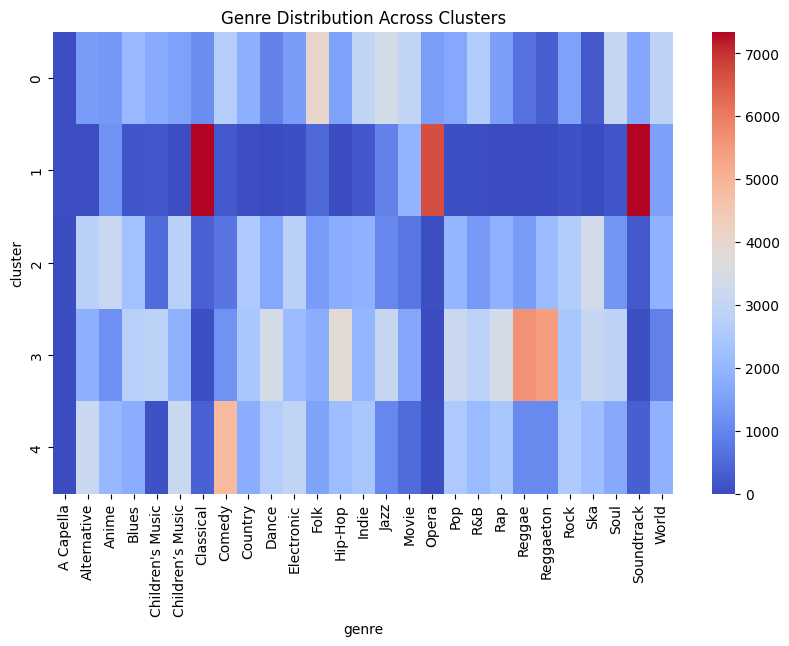


Recommended Songs:
0          C'est beau de faire un Show
1     Perdu d'avance (par Gad Elmaleh)
19                Ladies And Gentlemen
43                  To Be or Not to Be
51        Animauxville (Départ) - Live
Name: track_name, dtype: object


In [45]:
# 1️⃣ Cluster Analysis (Music Mood / Characteristics)

cluster_summary = df.groupby('cluster')[['danceability','energy','loudness','tempo','valence']].mean()

print("Cluster Audio Characteristics:")
print(cluster_summary)


# 2️⃣ Genre Discovery (Which genres fall in each cluster)

genre_cluster = pd.crosstab(df['cluster'], df['genre'])

print("\nGenre distribution across clusters:")
print(genre_cluster)


# Visualization
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(genre_cluster, cmap="coolwarm")
plt.title("Genre Distribution Across Clusters")
plt.show()


# 3️⃣ Song Recommendation System

def recommend_songs(song_name):

    if song_name not in df['track_name'].values:
        return "Song not found"

    song_cluster = df[df['track_name']==song_name]['cluster'].values[0]

    recommendations = df[df['cluster']==song_cluster]['track_name'].head(5)

    return recommendations


# Example Recommendation
print("\nRecommended Songs:")
print(recommend_songs(df['track_name'].iloc[0]))

In [54]:
# Install gradio
!pip install gradio

# Import libraries
import pandas as pd
import numpy as np
import gradio as gr
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Load dataset
df = pd.read_csv("SpotifyFeatures.csv")

# Select audio features
features = ['danceability','energy','loudness','tempo','valence']
X = df[features]

# Remove missing values
X = X.dropna()
df = df.loc[X.index]

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply KMeans clustering
kmeans = KMeans(n_clusters=5, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

# Cluster analysis
cluster_summary = df.groupby('cluster')[features].mean()
print("Cluster Characteristics:")
print(cluster_summary)

# Genre discovery
genre_cluster = pd.crosstab(df['cluster'], df['genre'])
print("\nGenre distribution across clusters:")
print(genre_cluster)

# Recommendation system
def recommend_songs(song_name):

    if song_name not in df['track_name'].values:
        return "Song not found in dataset"

    song_cluster = df[df['track_name']==song_name]['cluster'].values[0]

    recommendations = df[df['cluster']==song_cluster]['track_name'].head(5)

    return "\n".join(recommendations)

# Web app
interface = gr.Interface(
    fn=recommend_songs,
    inputs=gr.Textbox(label="Enter Song Name"),
    outputs=gr.Textbox(label="Recommended Songs"),
    title="Spotify Smart Music Discovery System",
    description="Enter a song name to get similar songs based on audio characteristics."
)

interface.launch()

Cluster Characteristics:
         danceability    energy   loudness       tempo   valence
cluster                                                         
0            0.558582  0.363649 -11.856957  114.804062  0.328522
1            0.265238  0.134341 -21.359480   98.652256  0.132196
2            0.503520  0.751289  -6.134783  160.012168  0.505394
3            0.727116  0.666534  -7.317571  111.974085  0.733104
4            0.548222  0.749618  -6.320722  100.064440  0.371678

Genre distribution across clusters:
genre    A Capella  Alternative  Anime  Blues  Children's Music  \
cluster                                                           
0               36         1429   1332   2079              1734   
1               53           37   1216    150               178   
2                9         2807   3140   2268               520   
3               17         1855   1204   2735              2859   
4                4         3135   2044   1791               112   

genre    Chil